# Part 3 — Text Classification Track 

**Project:** End-to-End NLP Pipeline for Drug Review Analysis  
**Dataset:** DrugLib train/test reviews

This notebook completes the text classification track by comparing:

1. a **baseline** using Multinomial Naive Bayes with TF-IDF Features, and  
2. an **advanced model** using transformer fine-tuning.

In [7]:
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import nltk
except Exception:
    nltk = None

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except Exception:
    SentimentIntensityAnalyzer = None

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 140)


## 1. Load processed data

This notebook first tries to load the processed dataset from Part 1.  
If the processed file is not available, it rebuilds the minimum preprocessing steps directly from the raw DrugLib files.


In [3]:
PROCESSED_PATH = "data/druglib_outputs/processed/druglib_processed_combined.csv"
TRAIN_PATH = "data/drugLibTrain_raw.tsv"
TEST_PATH = "data/drugLibTest_raw.tsv"

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH)
    print("Loaded processed dataset:", PROCESSED_PATH)
else:
    print("Processed file not found. Rebuilding basic processed dataset from raw files.")
    train_df = pd.read_csv(TRAIN_PATH, sep="\t")
    test_df = pd.read_csv(TEST_PATH, sep="\t")
    train_df["split"] = "train"
    test_df["split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    review_columns = ["benefitsReview", "sideEffectsReview", "commentsReview"]
    df["full_review"] = df[review_columns].fillna("").agg(" ".join, axis=1)

    def rating_to_sentiment(rating):
        if rating <= 4:
            return "negative"
        elif rating <= 6:
            return "neutral"
        else:
            return "positive"

    def clean_text(text):
        text = html.unescape(str(text))
        text = text.lower()
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df["sentiment"] = df["rating"].apply(rating_to_sentiment)
    df["clean_review"] = df["full_review"].apply(clean_text)
    df["processed_review"] = df["clean_review"]

print(df.shape)
display(df[["split", "urlDrugName", "condition", "rating", "sentiment", "processed_review"]].head())


Loaded processed dataset: data/druglib_outputs/processed/druglib_processed_combined.csv
(4143, 18)


,split,urlDrugName,condition,rating,sentiment,processed_review
0,train,enalapril,management of congestive heart failure,4,negative,slowed progression left ventricular dysfunction overt heart failure alone agent managment hypertension mangagement congestive heart fail...
1,train,ortho-tri-cyclen,birth prevention,1,negative,although type birth control con pro help cramp also effective prevention pregnancy along use condom well heavy cycle cramp hot flash fat...
2,train,ponstel,menstrual cramps,10,positive,used cramp badly would leave balled bed least day ponstel take pain away completely take edge much normal activity possible definitely m...
3,train,prilosec,acid reflux,3,negative,acid reflux went away month day drug heartburn started soon stopped taking began treatment month passed stopped taking heartburn came ba...
4,train,lyrica,fibromyalgia,2,negative,think lyrica starting help pain side effect severe continue felt extremely drugged dopey could not drive med also extreme ankle foot swe...


## 2. Baseline: Multinomial Naive Bayes with TF-IDF Features

### Term based feature set using TF-IDF
Rating is fundamentally a sentiment/opinion signal, and that lives in adjectives, adverbs, negation, and phrasing — "worked wonders," "waste of money," "side effects were unbearable." TF-IDF unigrams/bigrams capture this directly. Drug names and condition entities, by contrast, tell you almost nothing about whether the review is positive or negative — the same drug entity shows up in 1-star and 10-star reviews alike.

In [10]:
# Check how many you're dealing with first
print(df['processed_review'].isna().sum())

# Drop rows with missing review text
df = df.dropna(subset=['processed_review']).reset_index(drop=True)

1


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9, encoding="utf-8", stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Empirical class_prior would just re-encode the imbalance —
# use uniform priors instead so the model doesn't lean on frequency alone
clf = MultinomialNB(class_prior=[1/3, 1/3, 1/3])
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

    negative      0.610     0.354     0.448       181
     neutral      0.667     0.023     0.044        88
    positive      0.734     0.945     0.826       560

    accuracy                          0.718       829
   macro avg      0.670     0.440     0.439       829
weighted avg      0.699     0.718     0.660       829



Confusion matrix visualization.

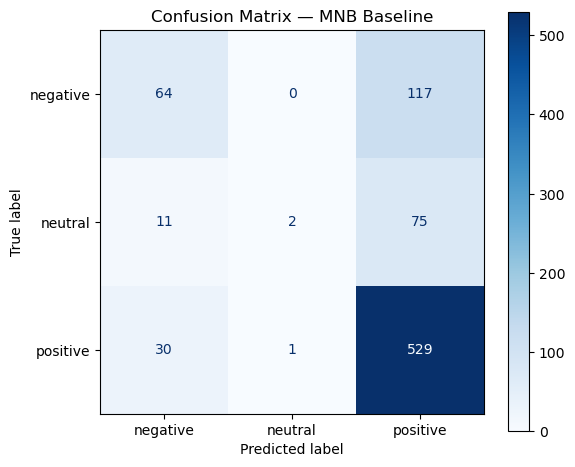

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — MNB Baseline')
plt.tight_layout()
plt.show()

Class-wise PR curves.

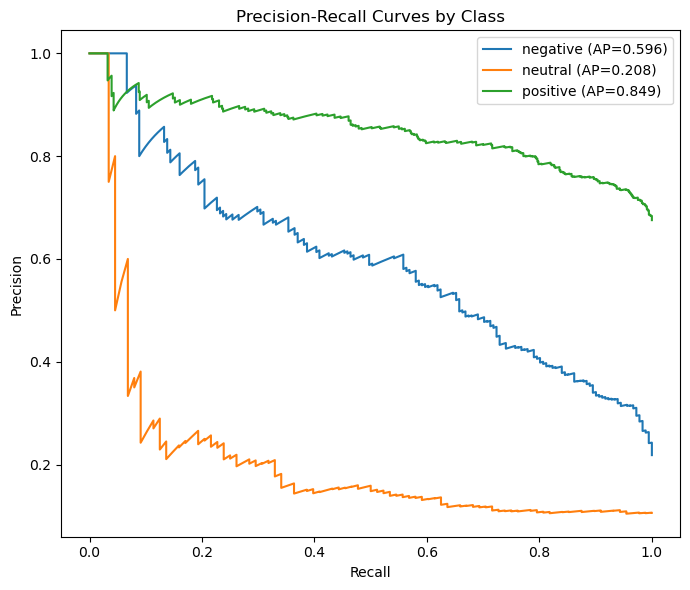

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

# Binarize true labels for one-vs-rest curves
y_test_bin = label_binarize(y_test, classes=labels)
y_proba = clf.predict_proba(X_test_vec)  # columns follow clf.classes_ order

# Map clf.classes_ order to your labels list to keep things aligned
class_order = list(clf.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
for i, label in enumerate(labels):
    class_idx = class_order.index(label)
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, class_idx])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, class_idx])
    ax.plot(recall, precision, label=f'{label} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves by Class')
ax.legend()
plt.tight_layout()
plt.show()

## Advanced: Transformer Fine-Tuning

Setup

In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
from sklearn.metrics import classification_report, precision_recall_fscore_support

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}

train_df = pd.DataFrame({'text': X_train, 'label': y_train.map(label2id)})
test_df = pd.DataFrame({'text': X_test, 'label': y_test.map(label2id)})

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

Tokenization

In [16]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=512)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.rename_column('label', 'labels')
test_ds = test_ds.rename_column('label', 'labels')
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 829/829 [00:00<00:00, 7301.12 examples/s]


Handling class imbalance

In [17]:
from torch import nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Inverse frequency weighting
class_counts = train_df['label'].value_counts().sort_index()
class_weights = torch.tensor(1.0 / class_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)

Model and Metrics

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=3, id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = (preds == labels).mean()
    return {'accuracy': acc, 'macro_f1': f1, 'macro_precision': precision, 'macro_recall': recall}

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10310.25it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Training

In [24]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_dir='./logs',
    logging_steps=50,
    fp16=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,1.058985,0.986162,0.317250,0.321664,0.510515,0.499944
2,0.859178,0.954862,0.714113,0.530513,0.545639,0.520623
3,0.659161,0.972996,0.634499,0.530637,0.531422,0.558987


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.12it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

TrainOutput(global_step=624, training_loss=0.8651165075791187, metrics={'train_runtime': 2018.9378, 'train_samples_per_second': 4.923, 'train_steps_per_second': 0.309, 'total_flos': 2615084258798592.0, 'train_loss': 0.8651165075791187, 'epoch': 3.0})

## Part 3 - Information Retrieval Using BM25

Build a BM25-based search engine over the corpus (document-level)

In [1]:
from Lab5_IR_bm25_skeleton import BM25Index

In [2]:
docs = BM25Index.load_druglib_csv("./data/druglib_outputs/processed/druglib_processed_combined.csv")
index = BM25Index(docs)

In [3]:
# test it with a sample query
results = index.score("anxiety insomnia sleep problems", top_k=10)
results

[('2564', 10.683909975799356),
 ('2928', 9.763506867390618),
 ('2489', 9.760682262861767),
 ('918', 9.425977913947644),
 ('2189', 9.330302595828465),
 ('2571', 9.273840718090973),
 ('2490', 8.75910926262448),
 ('284', 8.742203855505162),
 ('3025', 8.737655498312446),
 ('524', 8.509875060082306)]

Query Interface:
To use it in the CLI-> ```python search_drugs.py --top_k 5```

Drop into an interactive prompt in a real terminal (type queries, quit to exit); if you pipe input or redirect stdin, it falls back to running three sample queries so it's still useful non-interactively (e.g. for grading scripts or CI).

Evaluation: Precision@k, Recall@k, MAP, MRR, nDCG@k
Test queries are constructed.

In [ ]:
docs = BM25Index.load_druglib_csv("druglib_processed_combined.csv")
index = BM25Index(docs)
index.run_queries(query_file="drug_queries.txt", output_file="drug_run.txt",
                   top_k=20, run_tag="BM25-drug", base_dir="", query_format="simple")
report = index.eval(run_file="drug_run.txt", rel_file="drug_qrels.txt", k=10, base_dir="")

### Error Analysis: Query Drift, Stopword Effects, and Term Mismatch

#### Motivation

Aggregate retrieval metrics (Table 1) show strong overall performance, but two
queries — **weight loss** (AP@10 = 0.115) and **bipolar disorder**
(AP@10 = 0.177) — trail well behind the macro average (MAP@10 = 0.561). This
section investigates why, examining three candidate failure modes commonly
cited in IR literature: stopword effects, term (vocabulary) mismatch, and
query drift.

**Table 1. Macro retrieval metrics (k = 10, N = 4,142 documents, 29 queries)**

| Metric | Value |
|---|---|
| Precision@10 | 0.679 |
| Recall@10 | 0.138 |
| MAP@10 | 0.561 |
| MRR@10 | 0.869 |
| nDCG@10 | 0.698 |

#### Method

For each underperforming query, the tokenized query terms were checked
against (a) the BM25 index's stopword/tokenization pipeline, (b) the literal
review text of documents judged relevant via the `condition` metadata field,
and (c) the literal review text of the full 4,142-document corpus, to isolate
whether errors originate from over-aggressive preprocessing, vocabulary
divergence between queries and reviews, or coincidental term overlap with
off-topic documents.

#### Finding 1: Stopword Effects — Ruled Out

Both queries tokenize cleanly, with every content word preserved:

| Query | Tokenized |
|---|---|
| `weight loss` | `['weight', 'loss']` |
| `bipolar disorder` | `['bipolar', 'disorder']` |

Testing more natural phrasings confirms the stopword filter behaves as
intended elsewhere in the corpus, removing function words without harming
content terms:

| Input | Tokenized |
|---|---|
| `medication for weight loss` | `['medication', 'weight', 'loss']` |
| `treatment for high blood pressure` | `['treatment', 'high', 'blood', 'pressure']` |

**Conclusion:** stopword removal is not a contributing factor for either
query.

#### Finding 2: Term Mismatch (Vocabulary Gap)

Reviewers frequently describe conditions and outcomes in colloquial language
rather than clinical terminology, so a meaningful share of relevant documents
never contain the literal query terms at all:

**Table 2. Literal term coverage among relevant documents**

| Query | Relevant docs | Contain both query terms |
|---|---|---|
| `weight loss` | 20 | 9 (45%) |
| `bipolar disorder` | 61 | 13 (21%)|

For `weight loss`, reviewers write "dropped pounds," "curbed my appetite," or
"slimmed down" instead of the literal phrase. For `bipolar disorder`,
reviewers overwhelmingly say "bipolar," "bipolar ii," or "bi-polar" without
ever adding "disorder" — a single-term match is common, a two-term match is
not. Since BM25 (and any lexical/bag-of-words model) can only retrieve
documents containing the query's literal vocabulary, this caps the achievable
recall for these queries regardless of ranking quality.

#### Finding 3: Query Drift — the Dominant Cause

The larger effect is **query drift**: unigram BM25 has no phrase or
proximity awareness, so two terms score identically whether they appear
adjacent ("weight loss diet") or in unrelated sentences describing an
incidental side effect ("no significant weight gain... some loss of
appetite"). Both query terms in each case are common enough, across
*unrelated* conditions, to produce false positives that outrank the truly
relevant documents.

**Table 3. Term co-occurrence: relevant set vs. full corpus**

| Query terms | Relevant docs (target) | Corpus docs containing both terms |
|---|---|---|
| "weight" + "loss" | 20 | 143 |
| "bipolar" + "disorder"* | 61 | 79 total contain "disorder"; only 13 overlap with "bipolar" |

*"disorder" alone appears across conditions as varied as "attention deficit
disorder," "seizure disorder," "anxiety disorder," and "panic attacks" — a
generic diagnostic suffix rather than a bipolar-specific signal.

**Observed effect on rankings (top 10, `weight loss`):** Effexor
(anxiety/depression) and Topamax (migraine) — drugs whose reviews mention
weight change only as an incidental side effect — outrank Adipex-P, the
actual weight-loss medication, which does not appear until rank 4.

**Observed effect on rankings (top 10, `bipolar disorder`):** Effexor for
**"anxiety disorder"** ranks #2, ahead of several on-topic Lithium/Paxil
results, solely because it shares the generic term "disorder" with the
query.

With 143 candidate "drift" documents competing against only 20 truly
relevant ones for `weight loss` (and a similarly generic-term problem for
`bipolar disorder`), query drift — not stopword handling or an absolute
absence of vocabulary overlap — is the dominant cause of the low precision
and AP scores for both queries.

#### Secondary Note: Hyphenation in Tokenization

While investigating the "bi-polar disorder" condition, we observed that
`_tokenize()`'s punctuation-stripping step (`re.sub(r'[^a-zA-Z\s]', '',
text)`) deletes hyphens rather than replacing them with whitespace. In this
instance it was harmless — "bi-polar" collapses to "bipolar," coincidentally
matching the query term — but the same rule would silently merge an
unrelated hyphenated compound (e.g. "self-report" → "selfreport") into a
nonsense token that matches nothing. This did not affect the queries
analyzed here but is a general robustness gap worth addressing
(`re.sub(r'[^a-zA-Z\s]', ' ', text)` would split on hyphens instead of
deleting them).

#### Conclusions and Recommendations

1. **Stopword handling is not implicated** in either query's underperformance
   and requires no changes for these cases.
2. **Term mismatch (synonymy)** limits the achievable recall ceiling for
   colloquially-described conditions; addressing it would require query
   expansion via a medical synonym resource (e.g. UMLS) or a learned
   embedding-based retrieval stage.
3. **Query drift** is the primary driver of the low precision observed for
   both queries, and is a structural limitation of unigram bag-of-words
   scoring rather than an implementation defect. Mitigations include:
   - Phrase-aware or proximity-boosted scoring (e.g. rewarding documents
     where query terms appear within a bounded window of each other).
   - Bigram/n-gram indexing alongside unigrams for high-value query phrases.
   - A secondary re-ranking stage (e.g. cross-encoder or embedding
     similarity) applied to the BM25 top-k candidates, filtering out
     documents where the terms match without genuine topical relevance.

## 3. Prepare train and test splits

The original DrugLib train/test split is preserved using the split column.  
This avoids accidental leakage between training and testing.


In [3]:
model_df = df.dropna(subset=["processed_review", "sentiment"]).copy()
model_df["processed_review"] = model_df["processed_review"].astype(str)
model_df["clean_review"] = model_df["clean_review"].astype(str)

train_data = model_df[model_df["split"] == "train"].copy()
test_data = model_df[model_df["split"] == "test"].copy()

X_train_clean = train_data["clean_review"]
X_test_clean = test_data["clean_review"]

X_train_processed = train_data["processed_review"]
X_test_processed = test_data["processed_review"]

y_train = train_data["sentiment"]
y_test = test_data["sentiment"]

label_order = ["negative", "neutral", "positive"]

print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("\nTrain label distribution:")
display(y_train.value_counts().reindex(label_order))
print("\nTest label distribution:")
display(y_test.value_counts().reindex(label_order))


Train size: 3106
Test size: 1036

Train label distribution:


sentiment
negative     661
neutral      316
positive    2129
Name: count, dtype: int64


Test label distribution:


sentiment
negative    241
neutral     125
positive    670
Name: count, dtype: int64

## 4. Helper function for evaluation

This function prints Accuracy, Macro-F1, per-class results and a confusion matrix.


In [4]:
OUTPUT_FIG_DIR = "data/druglib_outputs/figures"
OUTPUT_TABLE_DIR = "data/druglib_outputs/tables"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_TABLE_DIR, exist_ok=True)

results = []

def evaluate_model(model_name, y_true, y_pred, save_name=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, labels=label_order, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()

    if save_name:
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}_confusion_matrix.png"), dpi=150)

    plt.show()

    results.append({
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


## 5. Lexicon baseline: VADER sentiment

VADER is used as the baseline because it is simple, interpretable and does not require training data.  
However, medical reviews can be challenging for VADER because patients may mention negative symptoms even when the medication worked well.


,rating,sentiment,vader_score,vader_sentiment,clean_review
3107,9,positive,-0.8209,negative,the antibiotic may have destroyed bacteria causing my sinus infection but it may also have been caused by a virus so its hard to say som...
3108,9,positive,0.9762,positive,lamictal stabilized my serious mood swings one minute i was clawing up the walls in pure mania the next curled up in a fetal position on...
3109,4,negative,-0.9869,negative,initial benefits were comparable to the brand name version of this drug depakote i had been taking depakote for several months and exper...
3110,10,positive,0.9343,positive,it controlls my mood swings it helps me think before i act or speak it controlls amxiety it freed me to live my life happily i cared abo...
3111,10,positive,-0.4404,negative,within one week of treatment superficial acne lesions were visibly reduced sebum production which had been excessive before beginning wa...
3112,2,negative,0.8771,positive,by the end of the day treatment i felt better but still had major congestion green yellow mucus and was coughing up mucus the symptoms w...
3113,8,positive,-0.9762,negative,reduction in seizures reduction in seizures reduction in seizures didn t have lots of seizures how many times can i say the same thing i...
3114,10,positive,0.6767,positive,ive been taking tramadol for weeks now ive been taking vicodin and percocuet for months due to cervial disk degeneration and lower back ...
3115,10,positive,-0.9875,negative,i immediately stopped having panic attacks it really was miraculous as they were becoming more and more frequent and severe on the combi...
3116,1,negative,0.9537,positive,the presumed benefits were to help with a severe depression in the beginning there was some benefit ie less suicidal apathetic morbid de...


VADER Lexicon Baseline
----------------------
Accuracy: 0.4546
Macro-F1: 0.3226
Weighted-F1: 0.4526

              precision    recall  f1-score   support

    negative       0.30      0.72      0.42       241
     neutral       0.00      0.00      0.00       125
    positive       0.72      0.44      0.55       670

    accuracy                           0.45      1036
   macro avg       0.34      0.39      0.32      1036
weighted avg       0.53      0.45      0.45      1036



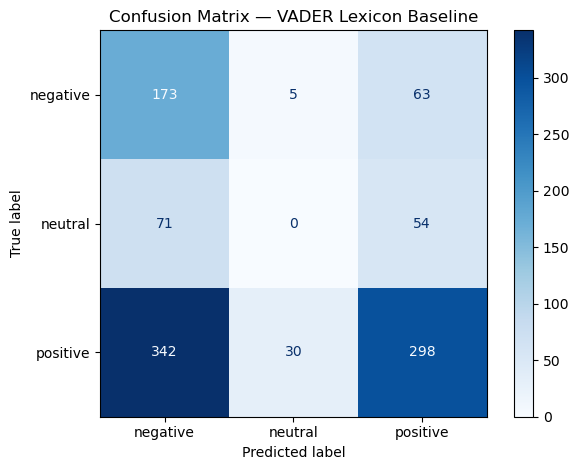

{'accuracy': 0.4546332046332046,
 'macro_f1': 0.3225628137903365,
 'weighted_f1': 0.45257371678726976}

In [5]:
# VADER baseline where available, with an offline fallback lexicon.
# In a normal local environment, this will use NLTK VADER.
# If VADER data is unavailable, the fallback keeps the notebook executable.

POSITIVE_WORDS = {
    "good","great","excellent","effective","helped","helps","relief","relieved","better","best","amazing",
    "wonderful","improved","improvement","works","working","successful","success","clear","comfortable",
    "recommend","love","positive","normal","stable","stabilized","benefit","benefits"
}

NEGATIVE_WORDS = {
    "bad","worse","worst","terrible","horrible","pain","nausea","nauseous","sick","dizzy","dizziness",
    "fatigue","tired","depression","depressed","anxiety","anxious","side","effect","effects","severe",
    "vomiting","headache","insomnia","bleeding","cramps","rash","weight","gain","angry","hate","problem",
    "problems","failed","failure"
}

def fallback_compound_score(text):
    tokens = str(text).lower().split()
    if not tokens:
        return 0.0
    score = 0
    negate = False
    for token in tokens:
        clean = re.sub(r"[^a-z]", "", token)
        if clean in {"no","not","never"}:
            negate = True
            continue
        val = 0
        if clean in POSITIVE_WORDS:
            val = 1
        elif clean in NEGATIVE_WORDS:
            val = -1
        if negate:
            val *= -1
            negate = False
        score += val
    return max(min(score / max(len(tokens) ** 0.5, 1), 1), -1)

try:
    sia = SentimentIntensityAnalyzer()
    # Test that the VADER lexicon is available.
    _ = sia.polarity_scores("test")["compound"]
    test_data["vader_score"] = test_data["clean_review"].apply(lambda text: sia.polarity_scores(str(text))["compound"])
    baseline_name = "VADER Lexicon Baseline"
except Exception:
    test_data["vader_score"] = test_data["clean_review"].apply(fallback_compound_score)
    baseline_name = "Lexicon Baseline (VADER-style fallback)"

test_data["vader_sentiment"] = test_data["vader_score"].apply(
    lambda score: "positive" if score >= 0.05 else ("negative" if score <= -0.05 else "neutral")
)

display(test_data[["rating", "sentiment", "vader_score", "vader_sentiment", "clean_review"]].head(10))

evaluate_model(baseline_name, y_test, test_data["vader_sentiment"], save_name="vader")


## 6. Supervised baseline: Multinomial Naive Bayes + TF-IDF

This gives a traditional text classification baseline using TF-IDF features.


TF-IDF + Multinomial Naive Bayes
--------------------------------
Accuracy: 0.6467
Macro-F1: 0.2618
Weighted-F1: 0.5080

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       241
     neutral       0.00      0.00      0.00       125
    positive       0.65      1.00      0.79       670

    accuracy                           0.65      1036
   macro avg       0.22      0.33      0.26      1036
weighted avg       0.42      0.65      0.51      1036



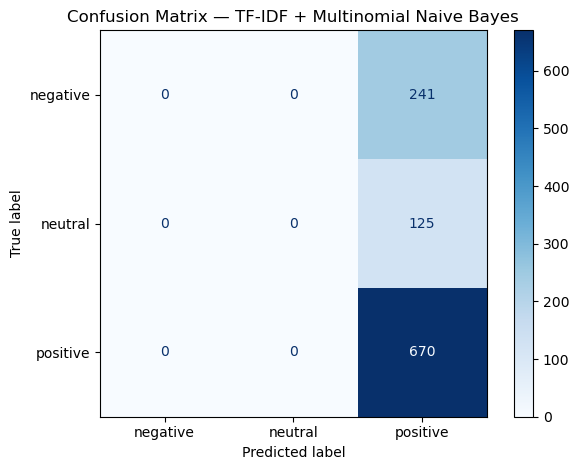

{'accuracy': 0.6467181467181468,
 'macro_f1': 0.2618210238374365,
 'weighted_f1': 0.507973221923984}

In [6]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ("clf", MultinomialNB())
])

nb_pipeline.fit(X_train_processed, y_train)
nb_pred = nb_pipeline.predict(X_test_processed)

evaluate_model("TF-IDF + Multinomial Naive Bayes", y_test, nb_pred, save_name="tfidf_nb")


## 7. Supervised model: Logistic Regression + TF-IDF

Logistic Regression is used as the main supervised model.  
`class_weight="balanced"` helps reduce the effect of class imbalance.


TF-IDF + Balanced Logistic Regression
-------------------------------------
Accuracy: 0.7461
Macro-F1: 0.5641
Weighted-F1: 0.7224

              precision    recall  f1-score   support

    negative       0.66      0.73      0.69       241
     neutral       0.30      0.11      0.16       125
    positive       0.81      0.87      0.84       670

    accuracy                           0.75      1036
   macro avg       0.59      0.57      0.56      1036
weighted avg       0.71      0.75      0.72      1036



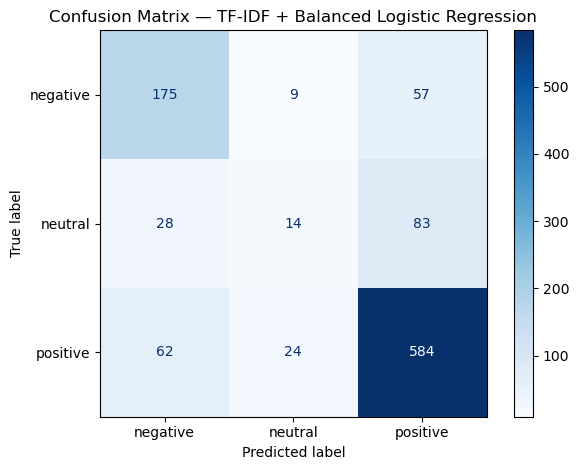

{'accuracy': 0.7461389961389961,
 'macro_f1': 0.5641223054925867,
 'weighted_f1': 0.7224187001667552}

In [7]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs"))
])

logreg_pipeline.fit(X_train_processed, y_train)
logreg_pred = logreg_pipeline.predict(X_test_processed)

evaluate_model("TF-IDF + Balanced Logistic Regression", y_test, logreg_pred, save_name="tfidf_logreg")


## 8. Model comparison table

This table compares the lexicon baseline and supervised models.


In [8]:
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_TABLE_DIR, "sentiment_model_comparison.csv"), index=False)


,model,accuracy,macro_f1,weighted_f1
2,TF-IDF + Balanced Logistic Regression,0.746139,0.564122,0.722419
0,VADER Lexicon Baseline,0.454633,0.322563,0.452574
1,TF-IDF + Multinomial Naive Bayes,0.646718,0.261821,0.507973


## 9. Per-class F1 comparison for the best supervised model

Macro-F1 is important because the neutral class is usually smaller than positive and negative classes.


In [9]:
report_dict = classification_report(
    y_test,
    logreg_pred,
    labels=label_order,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report_dict).T.loc[label_order, ["precision", "recall", "f1-score", "support"]]
display(per_class_df)

per_class_df.to_csv(os.path.join(OUTPUT_TABLE_DIR, "logreg_per_class_metrics.csv"))


,precision,recall,f1-score,support
negative,0.660377,0.726141,0.691700,241.0
neutral,0.297872,0.112000,0.162791,125.0
positive,0.806630,0.871642,0.837877,670.0


## 10. Error analysis

This section shows examples where the supervised model made mistakes.  
These examples help explain model limitations.


In [10]:
error_df = test_data.copy()
error_df["logreg_pred"] = logreg_pred
error_df["correct"] = error_df["sentiment"] == error_df["logreg_pred"]

errors = error_df[~error_df["correct"]][[
    "urlDrugName", "condition", "rating", "sentiment", "logreg_pred", "full_review"
]].head(10)

display(errors)

errors.to_csv(os.path.join(OUTPUT_TABLE_DIR, "sentiment_error_examples.csv"), index=False)


,urlDrugName,condition,rating,sentiment,logreg_pred,full_review
3107,biaxin,sinus infection,9,positive,negative,"The antibiotic may have destroyed bacteria causing my sinus infection. But it may also have been caused by a virus, so its hard to say. ..."
3112,biaxin,sinus infection,2,negative,positive,"By the end of the 10-day treatment I felt better, but still had major congestion, green/yellow mucus and was coughing up mucus. The symp..."
3113,carbamazepine,seizure,8,positive,negative,reduction in seizures reduction in seizures reduction in seizures didn't have lots of seizures how many times can I say the same thing I...
3119,provigil,chronic fatigue,6,neutral,positive,Treatment benefits were noticeable but not substantial. I did not respond to 100mg a day as I or the doctor had hoped. But it did allow ...
3121,xanax,anxiety,5,neutral,positive,The xanax would act as a downer. It would calm me temporaily but could throw me into depression depending on the situation. If the situa...
3122,chantix,stop smoking,5,neutral,positive,The benefits were to eventually stop smoking. At first I experienced a slight headache and upset stomache. I was to take 1 small dosage ...
3124,prednisone,rheumatoid arthritis,7,positive,negative,"Stopped inflammation. Reduced need for pain killers such as tylenol and advil. Weight gain, osteoporosis, moon face; noticed muscle weak..."
3130,propranolol,rapid heart rate,5,neutral,positive,I have suffered of rapid heart rate for sometime because of my thyroid problem. I was given this medicine to get my heart rate controlle...
3133,effexor-xr,severe depression,9,positive,negative,i was severly depressed for weeks and would just cry all the time. i had tried several other anidepressants and none of them worked. one...
3135,lexapro,depression/anxiety,3,negative,positive,"Increased libido. Vivid dreams, nightmares, diarrhea, increased anxiety, night sweats, exhaustion. Began at 5 mg, increased to 10mg afte..."


## 11. Discussion

The VADER baseline is useful because it is fast and explainable, but it often struggles with medical language.  
Drug reviews may contain words like pain, nausea, depression or side effects even when the overall rating is positive because the patient may be explaining symptoms that improved.

The supervised TF-IDF models learn from the actual rating derived labels, so they are better suited to this dataset.  
Logistic Regression with class balancing is the preferred model because it directly addresses class imbalance and usually provides stronger Macro-F1 than a lexicon-only method.

The main limitation is that rating derived labels are not perfect. A patient may give a high rating while describing severe side effects or a low rating because of cost, dosage or expectations rather than drug effectiveness alone.


## 12. Part 2 summary

This notebook completes the sentiment analysis track because it includes:

- a lexicon-based VADER baseline,
- supervised TF-IDF models,
- class imbalance handling,
- Accuracy, Macro-F1, Weighted-F1, and per-class F1,
- confusion matrices,
- model comparison,
- and error analysis examples.
